# Financial Behavior and Customer Spending Analysis

## Project Description
This project analyzes customer financial behavior and spending patterns using banking transaction data. The main goal is to understand customer spending habits, transaction activities, and customer behavior patterns in a simple and meaningful way.

## Import Libraries

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [4]:
customer = pd.read_csv("C:/Users/suman/OneDrive/Desktop/Financial_Behavior_Project/data/customer_data.csv")
transactions = pd.read_csv("C:/Users/suman/OneDrive/Desktop/Financial_Behavior_Project/data/transaction_data.csv")
banks = pd.read_csv("C:/Users/suman/OneDrive/Desktop/Financial_Behavior_Project/data/bank_data.csv")

### Initial Exploration of customer data

In [5]:
customer.head()

,Customer_ID,Age,Customer_Type,City,Region,Bank_Name,Branch_ID
0,200000,56.0,Employee,Pune,North,HDFC Bank,1350
1,200001,69.0,NaN,Kolhapur,East,HDFC Bank,1648
2,200002,46.0,Business,Pune,West,HDFC Bank,1798
3,200003,32.0,Individual,Pune,West,HDFC Bank,1900
4,200004,NaN,Business,Kolhapur,East,HDFC Bank,1227


### Initial Exploration of Transaction Data

In [7]:
transactions.head()

,Transaction_ID,Customer_ID,Account_Type,Total_Balance,Transaction_Amount,Investment_Amount,Investment_Type,Transaction_Date
0,300000,209689,Business,69339,4794.0,42580,Fixed Deposit,2024-12-08
1,300001,206124,Business,12825,3500.0,46605,Fixed Deposit,2022-09-09
2,300002,207501,Current,67753,2401.0,17027,Fixed Deposit,2022-04-28
3,300003,208675,Savings,67061,2952.0,3054,Fixed Deposit,2023-05-22
4,300004,204923,Business,8566,1025.0,44937,Fixed Deposit,2023-04-05


### Initial Exploration of Bank Data

In [9]:
banks.head()

,Branch_ID,City,Region,Firm_Revenue,Expenses,Profit_Margin
0,1000,Solapur,East,422443.0,346471,56.31
1,1001,Mumbai,North,211155.0,216256,79.53
2,1002,Nashik,West,985006.0,71777,55.31
3,1003,Solapur,North,55113.0,253655,2.57
4,1004,Nagpur,West,282701.0,148194,-14.10


### Understanding the Size of the Dataset

In [17]:
customer.shape

(10000, 7)

In [20]:
transactions.shape

(10000, 8)

In [21]:
banks.shape

(1000, 6)

### understanding Dataset Variables

In [23]:
customer.columns

Index(['Customer_ID', 'Age', 'Customer_Type', 'City', 'Region', 'Bank_Name',
       'Branch_ID'],
      dtype='object')

In [24]:
transactions.columns

Index(['Transaction_ID', 'Customer_ID', 'Account_Type', 'Total_Balance',
       'Transaction_Amount', 'Investment_Amount', 'Investment_Type',
       'Transaction_Date'],
      dtype='object')

In [25]:
banks.columns

Index(['Branch_ID', 'City', 'Region', 'Firm_Revenue', 'Expenses',
       'Profit_Margin'],
      dtype='object')

### Structural Overview of the Dataset

In [26]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_ID    10000 non-null  int64  
 1   Age            9500 non-null   float64
 2   Customer_Type  9500 non-null   object 
 3   City           9500 non-null   object 
 4   Region         10000 non-null  object 
 5   Bank_Name      10000 non-null  object 
 6   Branch_ID      10000 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 547.0+ KB


In [27]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      10000 non-null  int64  
 1   Customer_ID         10000 non-null  int64  
 2   Account_Type        10000 non-null  object 
 3   Total_Balance       10000 non-null  int64  
 4   Transaction_Amount  10000 non-null  float64
 5   Investment_Amount   10000 non-null  int64  
 6   Investment_Type     10000 non-null  object 
 7   Transaction_Date    10000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 625.1+ KB


In [28]:
banks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch_ID      1000 non-null   int64  
 1   City           1000 non-null   object 
 2   Region         1000 non-null   object 
 3   Firm_Revenue   950 non-null    float64
 4   Expenses       1000 non-null   int64  
 5   Profit_Margin  1000 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 47.0+ KB


### Identifying Missing Values in the dataset

In [29]:
customer.isnull().sum()

Customer_ID        0
Age              500
Customer_Type    500
City             500
Region             0
Bank_Name          0
Branch_ID          0
dtype: int64

In [31]:
transactions.isnull().sum()

Transaction_ID        0
Customer_ID           0
Account_Type          0
Total_Balance         0
Transaction_Amount    0
Investment_Amount     0
Investment_Type       0
Transaction_Date      0
dtype: int64

In [37]:
banks.isnull().sum()

Branch_ID         0
City              0
Region            0
Firm_Revenue     50
Expenses          0
Profit_Margin     0
dtype: int64

### Missing Vakue Treatment

#### Check the percentage of missing values

In [32]:
(customer.isnull().sum()/len(customer))*100

Customer_ID      0.0
Age              5.0
Customer_Type    5.0
City             5.0
Region           0.0
Bank_Name        0.0
Branch_ID        0.0
dtype: float64

In [35]:
(transactions.isnull().sum()/len(transactions))*100

Transaction_ID        0.0
Customer_ID           0.0
Account_Type          0.0
Total_Balance         0.0
Transaction_Amount    0.0
Investment_Amount     0.0
Investment_Type       0.0
Transaction_Date      0.0
dtype: float64

In [36]:
(banks.isnull().sum()/len(banks))*100

Branch_ID        0.0
City             0.0
Region           0.0
Firm_Revenue     5.0
Expenses         0.0
Profit_Margin    0.0
dtype: float64

#### Handle Numerical Missing Values

In [38]:
customer["Age"] = customer["Age"].fillna(customer["Age"].median())

In [42]:
customer["Customer_Type"] = customer["Customer_Type"].fillna(customer["Customer_Type"].mode()[0])

In [43]:
customer["City"] = customer["City"].fillna(customer["City"].mode()[0])

In [45]:
customer.isnull().sum()

Customer_ID      0
Age              0
Customer_Type    0
City             0
Region           0
Bank_Name        0
Branch_ID        0
dtype: int64

In [47]:
banks["Firm_Revenue"] = banks["Firm_Revenue"].fillna(banks["Firm_Revenue"].median())

In [48]:
banks.isnull().sum()

Branch_ID        0
City             0
Region           0
Firm_Revenue     0
Expenses         0
Profit_Margin    0
dtype: int64

### Checking Duplicate Records

In [49]:
customer.duplicated().sum()

0

In [50]:
transactions.duplicated().sum()

0

In [51]:
banks.duplicated().sum()

0

### Statistical Summary of Numerical Variables

In [52]:
customer.describe()

,Customer_ID,Age,Branch_ID
count,10000.00000,10000.000000,10000.000000
mean,204999.50000,48.766700,1497.829300
std,2886.89568,17.465491,288.758237
min,200000.00000,18.000000,1000.000000
25%,202499.75000,34.000000,1246.000000
50%,204999.50000,49.000000,1499.000000
75%,207499.25000,64.000000,1747.000000
max,209999.00000,79.000000,1999.000000


In [54]:
transactions.describe()

,Transaction_ID,Customer_ID,Total_Balance,Transaction_Amount,Investment_Amount
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,304999.50000,205028.182600,50221.505800,2542.708056,25550.248400
std,2886.89568,2909.008139,28540.392011,1432.677420,14108.052078
min,300000.00000,200000.000000,1003.000000,51.613952,1001.000000
25%,302499.75000,202498.750000,25132.000000,1310.000000,13381.000000
50%,304999.50000,205060.000000,50326.000000,2538.500000,25708.500000
75%,307499.25000,207561.000000,74914.500000,3746.250000,37731.000000
max,309999.00000,209999.000000,99993.000000,7046.296441,49998.000000


In [55]:
banks.describe()

,Branch_ID,Firm_Revenue,Expenses,Profit_Margin
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,1499.500000,514287.897000,265325.99100,24.561410
std,288.819436,271603.853977,140572.96154,42.757352
min,1000.000000,51241.000000,20520.00000,-49.500000
25%,1249.750000,275117.750000,145412.75000,-13.470000
50%,1499.500000,518348.500000,265404.00000,24.320000
75%,1749.250000,738167.250000,394530.50000,61.475000
max,1999.000000,999975.000000,499568.00000,99.970000


#### Understanding Categorical Variables

In [56]:
customer["Customer_Type"].value_counts()

Customer_Type
Business      3686
Employee      3182
Individual    3132
Name: count, dtype: int64

In [57]:
transactions["Account_Type"].value_counts()

Account_Type
Current     3363
Savings     3346
Business    3291
Name: count, dtype: int64

In [62]:
transactions["Investment_Type"].value_counts()

Investment_Type
Recurring Deposit    3338
Fixed Deposit        3335
Mutual Fund          3327
Name: count, dtype: int64

## Data Visualizations and Exploratory Analysis

In [63]:
import seaborn as sns

#### Distribution of Customer Age

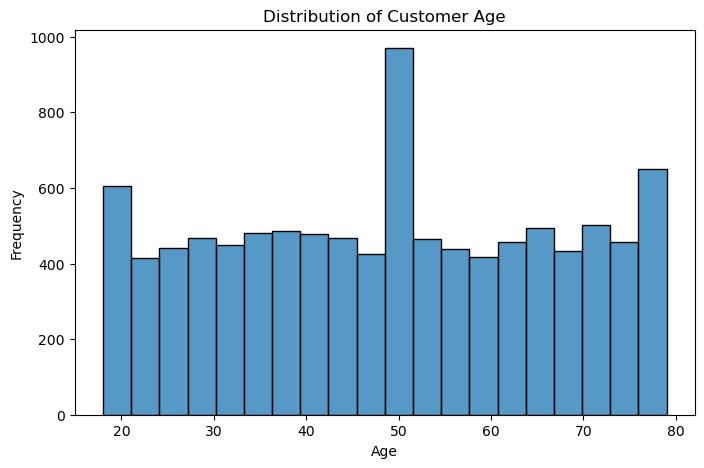

In [64]:
plt.figure(figsize=(8,5))
sns.histplot(customer["Age"], bins=20)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### Distribution of Customer Types

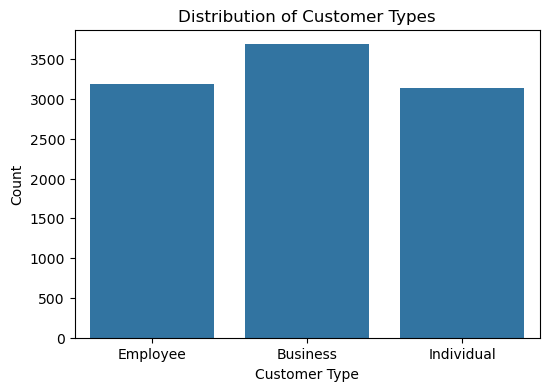

In [65]:
plt.figure(figsize=(6,4))
sns.countplot(x="Customer_Type", data=customer)
plt.title("Distribution of Customer Types")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

#### Distribution of Account Types

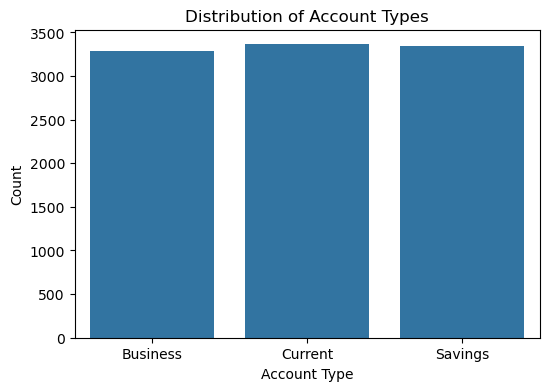

In [66]:
plt.figure(figsize=(6,4))
sns.countplot(x="Account_Type", data=transactions)
plt.title("Distribution of Account Types")
plt.xlabel("Account Type")
plt.ylabel("Count")
plt.show()

### Relationship Analysis

#### Distribution of Transaction Amount

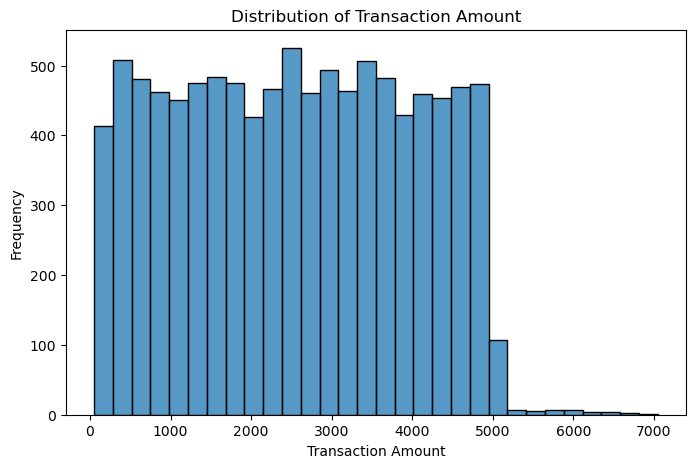

In [67]:
plt.figure(figsize=(8,5))
sns.histplot(transactions["Transaction_Amount"], bins=30)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

#### Relationship Between Customer Age and Total Balance

In [69]:
merged_data = pd.merge(customer, transactions, on="Customer_ID")

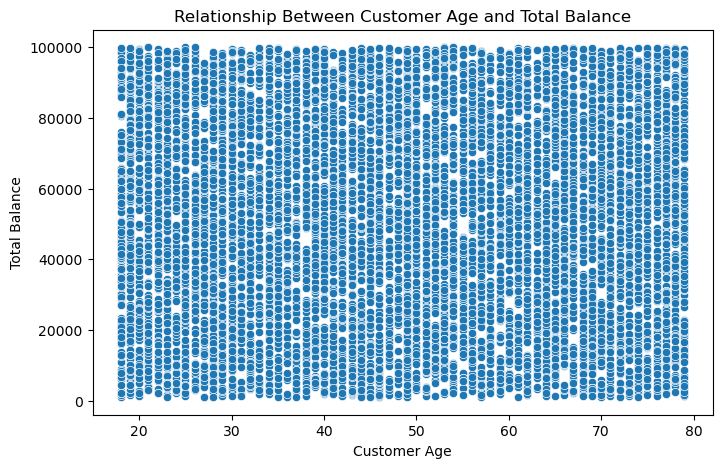

In [70]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Total_Balance", data=merged_data)
plt.title("Relationship Between Customer Age and Total Balance")
plt.xlabel("Customer Age")
plt.ylabel("Total Balance")
plt.show()

#### Investment Type Analysis

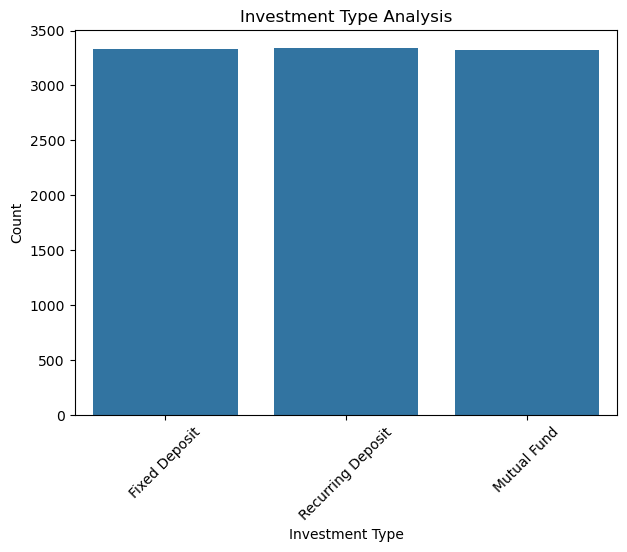

In [72]:
plt.figure(figsize=(7,5))
sns.countplot(x="Investment_Type", data=transactions)
plt.title("Investment Type Analysis")
plt.xlabel("Investment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Relationship Between Transaction Amount and Investment Amount

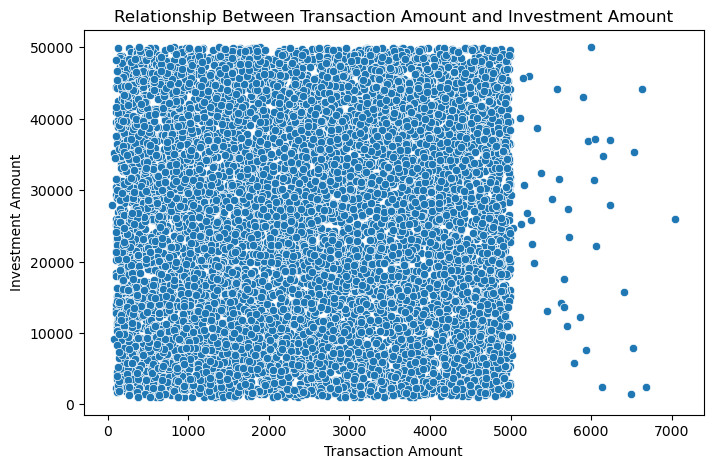

In [73]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Transaction_Amount",
                y="Investment_Amount",
                data=transactions)
plt.title("Relationship Between Transaction Amount and Investment Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Investment Amount")
plt.show()

### Correlation Analysis of Financial Variables
Correlation analysis helps identify the strength and direction of relationships between numerical financial variables in the dataset.

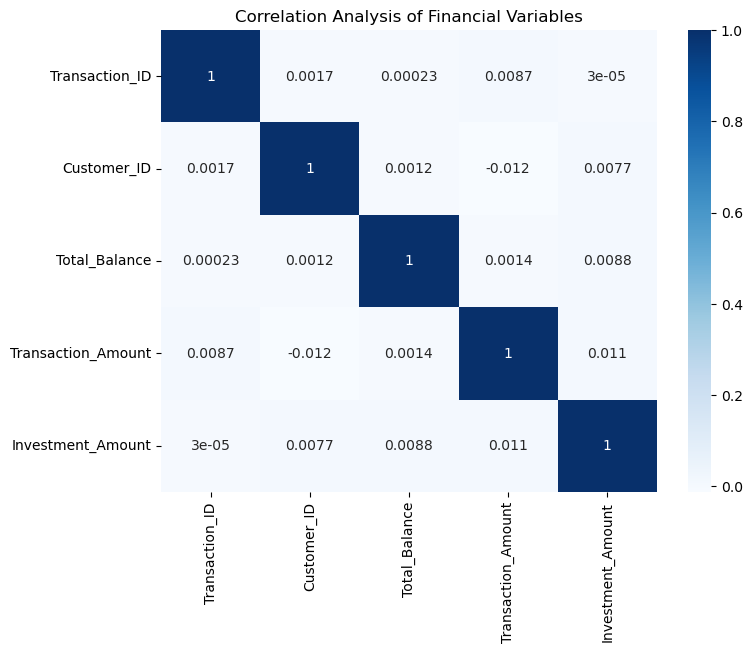

In [76]:
plt.figure(figsize=(8,6))
sns.heatmap(transactions.corr(numeric_only=True),
            annot=True,
            cmap="Blues")
plt.title("Correlation Analysis of Financial Variables")
plt.show()

#### Customer Segmentation Analysis
Customer segmentation helps identify groups of customers with similar financial behavior and transaction patterns.

In [77]:
from sklearn.cluster import KMeans

In [78]:
segmentation_data = merged_data[["Age",
                                 "Total_Balance",
                                 "Transaction_Amount",
                                 "Investment_Amount"]]

In [79]:
kmeans = KMeans(n_clusters=4, random_state=42)

In [80]:
merged_data["Cluster"] = kmeans.fit_predict(segmentation_data)

#### Customer Segments Based on Financial Behavior

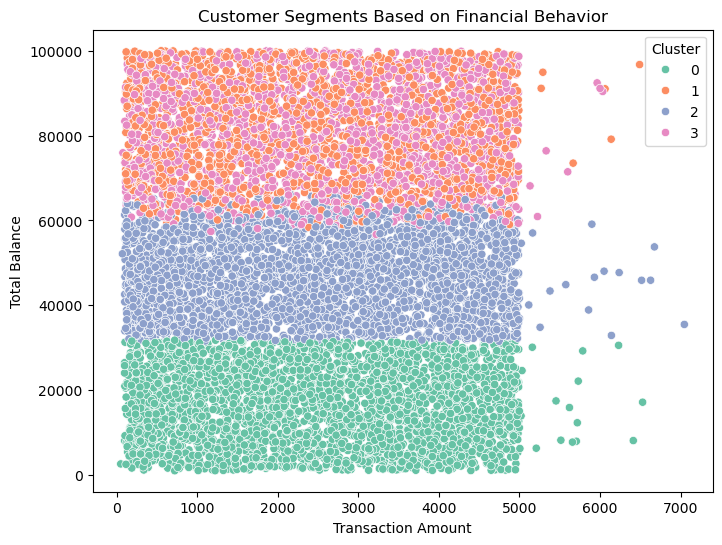

In [81]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Transaction_Amount",
                y="Total_Balance",
                hue="Cluster",
                data=merged_data,
                palette="Set2")
plt.title("Customer Segments Based on Financial Behavior")
plt.xlabel("Transaction Amount")
plt.ylabel("Total Balance")
plt.show()

### Customer Segmentation Analysis
Customer segmentation helps identify groups of customers with similar financial behavior and transaction patterns.

In [82]:
merged_data.groupby("Cluster")[["Age",
                                "Transaction_Amount",
                                "Total_Balance",
                                "Investment_Amount"]].mean()

,Age,Transaction_Amount,Total_Balance,Investment_Amount
Cluster,,,,
0,48.779421,2528.285743,16122.482637,25486.215113
1,49.610872,2523.377205,81510.962863,12963.885899
2,49.263481,2560.065938,47010.995157,25083.615757
3,48.771059,2556.668137,80120.783463,38485.528165


#### Cluster 0
Customers in this segment show moderate transaction activity and balanced financial behavior.

#### Cluster 1
This segment represents customers with high transaction amounts and higher investment activity.


#### Cluster 2
Customers in this cluster demonstrate lower financial balances and lower transaction activity.

#### Cluster 3
This segment includes financially active customers with relatively higher total balances and investment amounts.


### Final Insights and Conclusion
This project analyzed customer financial behavior and spending patterns using banking and transaction data. Different data analysis and visualization techniques were used to understand customer activities, transaction behavior, investment patterns, and financial characteristics.
The analysis showed that customers have different financial behaviors based on transaction amount, account balance, and investment activities. Some customers demonstrated stable financial behavior with higher balances and investment amounts, while other groups showed lower transaction and investment activities. The correlation analysis also helped identify relationships between important financial variables within the dataset.
Customer segmentation using the K-Means clustering algorithm grouped customers into different financial behavior categories. These segments helped provide a better understanding of customer spending and financial patterns. This type of analysis can help financial institutions better understand customer behavior and support decision-making processes.

From a banking perspective, understanding customer financial behavior is important for customer relationship management, financial planning, and business strategy development. Based on my previous banking experience, customer transaction behavior and financial activity often provide useful insights into customer needs, financial stability, and banking service preferences.

Overall, this project provided practical experience in data preprocessing, exploratory data analysis, visualization, and customer segmentation using machine learning techniques in a financial analytics environment.